In [39]:
import mytorch
import mytorch.layer
import mytorch.activation
import mytorch.optimizer
import mytorch.loss
import pandas as pd
import matplotlib.pyplot as plt
from mytorch.tensor import Tensor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
# from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import random

seed = 42
random.seed(seed)
np.random.seed(seed)
FILE_PATH = r".\diabetes.csv"

In [40]:
# #don't change this cell
df = pd.read_csv(FILE_PATH, header=0)

# Rename Outcome to Diagnosis and convert to binary (already 0/1)
df = df.rename(columns={"Outcome": "Diagnosis"})

df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diagnosis
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [41]:
columns_to_fix_med = ['Glucose', 'BloodPressure']
columns_to_fix_mea = ['BMI','SkinThickness','Insulin']

for col in columns_to_fix_mea:
    zero_count = (df[col] == 0).sum()
    df[col] = df[col].replace(0, np.nan)
    
    mean_value = df[col].mean()
    df[col] = df[col].replace(np.nan, mean_value)
    
for col in columns_to_fix_med:
    zero_count = (df[col] == 0).sum()
    df[col] = df[col].replace(0, np.nan)
    
    median_value = df[col].median()
    df[col] = df[col].replace(np.nan, median_value)

In [42]:
X = df.drop(columns=["Diagnosis"]).values
y = df["Diagnosis"].values
y = y.reshape(-1, 1) 

scaler= StandardScaler()
X = scaler.fit_transform(X)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42)

scaler= StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

X_train = mytorch.Tensor(X_train)
y_train = mytorch.Tensor(y_train)   

X_test_org = mytorch.Tensor(X_test)
y_test_org = mytorch.Tensor(y_test)

X_test = mytorch.Tensor(X_val)
y_test = mytorch.Tensor(y_val)



In [43]:
class msig(mytorch.Model):
    def __init__(self, input_size):
        super(msig, self).__init__()
        self.l1 = mytorch.layer.Linear(input_size, 64)
        self.l2 = mytorch.layer.Linear(64, 32)
        self.l3 = mytorch.layer.Linear(32, 16)
        self.l4 = mytorch.layer.Linear(16, 1)
        
        self.layers = [self.l1, self.l2, self.l3, self.l4]
        self.relu = mytorch.activation.relu
        self.sigmoid = mytorch.activation.sigmoid
    
    def forward(self, x):
        x = self.relu(self.l1(x))
        x = self.relu(self.l2(x))
        x = self.relu(self.l3(x))
        x = self.sigmoid(self.l4(x))
        return x
    
class mrelu(mytorch.Model):
    def __init__(self, input_size):
        super(mrelu, self).__init__()
        self.l1 = mytorch.layer.Linear(input_size, 64)
        self.l2 = mytorch.layer.Linear(64, 32)
        self.l3 = mytorch.layer.Linear(32, 16)
        self.l4 = mytorch.layer.Linear(16, 1)
        
        self.layers = [self.l1, self.l2, self.l3, self.l4]
        self.relu = mytorch.activation.relu
    
    def forward(self, x):
        x = self.relu(self.l1(x))
        x = self.relu(self.l2(x))
        x = self.relu(self.l3(x))
        x = self.relu(self.l4(x))
        return x
    
class mleaky(mytorch.Model):
    def __init__(self, input_size):
        super(mleaky, self).__init__()
        self.l1 = mytorch.layer.Linear(input_size, 64)
        self.l2 = mytorch.layer.Linear(64, 32)
        self.l3 = mytorch.layer.Linear(32, 16)
        self.l4 = mytorch.layer.Linear(16, 1)
        
        self.layers = [self.l1, self.l2, self.l3, self.l4]
        self.relu = mytorch.activation.relu
        self.leaky_relu = mytorch.activation.leaky_relu
            
    def forward(self, x):
        x = self.relu(self.l1(x))
        x = self.relu(self.l2(x))
        x = self.relu(self.l3(x))
        x = self.leaky_relu(self.l4(x))
        return x
    
    
class msoft(mytorch.Model):
    def __init__(self, input_size):
        super(msoft, self).__init__()
        self.l1 = mytorch.layer.Linear(input_size, 64)
        self.l2 = mytorch.layer.Linear(64, 32)
        self.l3 = mytorch.layer.Linear(32, 16)
        self.l4 = mytorch.layer.Linear(16, 1)
        
        self.layers = [self.l1, self.l2, self.l3, self.l4]
        self.relu = mytorch.activation.relu
        self.softmax = mytorch.activation.softmax
    
    def forward(self, x):
        x = self.relu(self.l1(x))
        x = self.relu(self.l2(x))
        x = self.relu(self.l3(x))
        x = self.softmax(self.l4(x))
        return x
    
class mstep(mytorch.Model):
    def __init__(self, input_size):
        super(mstep, self).__init__()
        self.l1 = mytorch.layer.Linear(input_size, 64)
        self.l2 = mytorch.layer.Linear(64, 32)
        self.l3 = mytorch.layer.Linear(32, 16)
        self.l4 = mytorch.layer.Linear(16, 1)
        
        self.layers = [self.l1, self.l2, self.l3, self.l4]
        self.relu = mytorch.activation.relu
        self.step= mytorch.activation.step
        
    def forward(self, x):
        x = self.relu(self.l1(x))
        x = self.relu(self.l2(x))
        x = self.relu(self.l3(x))
        x = self.step(self.l4(x))
        return x
    
class mtanh(mytorch.Model):
    def __init__(self, input_size):
        super(mtanh, self).__init__()
        self.l1 = mytorch.layer.Linear(input_size, 64)
        self.l2 = mytorch.layer.Linear(64, 32)
        self.l3 = mytorch.layer.Linear(32, 16)
        self.l4 = mytorch.layer.Linear(16, 1)
        
        self.layers = [self.l1, self.l2, self.l3, self.l4]
        self.relu = mytorch.activation.relu
        self.tanh = mytorch.activation.tanh
    
    def forward(self, x):
        x = self.relu(self.l1(x))
        x = self.relu(self.l2(x))
        x = self.relu(self.l3(x))
        x = self.tanh(self.l4(x))
        return x



In [44]:
y_train_binary = mytorch.Tensor(y_train.data.astype(float))
y_test_binary = mytorch.Tensor(y_test.data.astype(float))
input_size = X.shape[1]
NUM_EPOCHS = 50
# criterion = mytorch.loss.ce.BinaryCrossEntropy

model_sig = msig(input_size)
model_relu = mrelu(input_size)
model_leaky = mleaky(input_size)
model_soft = msoft(input_size)
model_step = mstep(input_size)
model_tanh = mtanh(input_size)


In [45]:
metrics_df = pd.DataFrame(columns=["Epoch", "Model", "Train_Loss", "Train_Accuracy", "Test_Loss", "Test_Accuracy"])
names = ['Sigmoid', 'ReLU', 'Leaky ReLU', 'Softmax', 'Step', 'Tanh']
models = [ model_sig , model_relu, model_leaky, model_soft, model_step, model_tanh ]


In [46]:

batch_size = 64
for mdl,name in zip(models, names):
    optimizer = mytorch.optimizer.Adam(mdl.layers, lr=0.0001)

    train_accuracy_list = []
    test_accuracy_list = []
    for epoch in range(NUM_EPOCHS):
        total = 0
        corrects = 0
        running_loss = 0.0

        for i in range(0, X_train.shape[0], batch_size):
            inputs = X_train[i:i+batch_size]
            labels = y_train[i:i+batch_size]
            
            optimizer.zero_grad()
            outputs = mdl.forward(inputs)
            
            loss = mytorch.loss.ce.BinaryCrossEntropy(outputs, labels) 
            loss = loss.sum()
            loss.backward()
            optimizer.step()
            
            running_loss += loss.data.sum()
            total += labels.data.shape[0]
            
            pred = (outputs.data > 0.5).astype(float)
            corrects += (pred == labels.data).astype(int).sum().item()
            
            
        epoch_loss = running_loss / total
        train_accuracy = corrects / total
        train_accuracy_list.append(train_accuracy)
        
        print(f"Epoch {epoch+1}/{NUM_EPOCHS}, Loss: {epoch_loss:.4f}, Accuracy: {train_accuracy:.4f}")
        
        
        outputs_test = mdl.forward(X_test)
        pred_test = (outputs_test.data > 0.5).astype(float)
        correct = (pred_test == y_test_binary.data).astype(int).sum().item()
        
        test_loss = mytorch.loss.ce.BinaryCrossEntropy(outputs_test, y_test_binary).data.sum() / y_test_binary.data.shape[0]
        total = y_test_binary.data.shape[0]
        test_accuracy = correct / total
        test_accuracy_list.append(test_accuracy)
        
        print(f"Test Accuracy: {test_accuracy:.4f}", end="\n\n")

    
        metrics_df = pd.concat([metrics_df, pd.DataFrame.from_dict([{
                "Epoch": epoch+1,
                "Model": name,
                "Train_Loss": epoch_loss,
                "Train_Accuracy": train_accuracy,
                "Test_Loss": test_loss,
                "Test_Accuracy": test_accuracy
            }])], ignore_index=True)
    

initialize cache
initialize cache
initialize cache
initialize cache
Epoch 1/50, Loss: 0.6788, Accuracy: 0.5870
Test Accuracy: 0.6623

Epoch 2/50, Loss: 0.6731, Accuracy: 0.6065
Test Accuracy: 0.6818

Epoch 3/50, Loss: 0.6677, Accuracy: 0.6152
Test Accuracy: 0.6753

Epoch 4/50, Loss: 0.6623, Accuracy: 0.6370
Test Accuracy: 0.6753

Epoch 5/50, Loss: 0.6569, Accuracy: 0.6457
Test Accuracy: 0.6753

Epoch 6/50, Loss: 0.6515, Accuracy: 0.6587
Test Accuracy: 0.6753

Epoch 7/50, Loss: 0.6459, Accuracy: 0.6565
Test Accuracy: 0.6883

Epoch 8/50, Loss: 0.6404, Accuracy: 0.6630
Test Accuracy: 0.6883

Epoch 9/50, Loss: 0.6347, Accuracy: 0.6696
Test Accuracy: 0.6883

Epoch 10/50, Loss: 0.6290, Accuracy: 0.6674
Test Accuracy: 0.6948

Epoch 11/50, Loss: 0.6233, Accuracy: 0.6674
Test Accuracy: 0.6948

Epoch 12/50, Loss: 0.6178, Accuracy: 0.6717
Test Accuracy: 0.7013

Epoch 13/50, Loss: 0.6123, Accuracy: 0.6804
Test Accuracy: 0.7013

Epoch 14/50, Loss: 0.6070, Accuracy: 0.6826
Test Accuracy: 0.7013

Epo

C:\Users\asus\AppData\Local\Temp\ipykernel_7544\3743558042.py:50: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df = pd.concat([metrics_df, pd.DataFrame.from_dict([{


Epoch 26/50, Loss: 0.5525, Accuracy: 0.7152
Test Accuracy: 0.7208

Epoch 27/50, Loss: 0.5487, Accuracy: 0.7196
Test Accuracy: 0.7208

Epoch 28/50, Loss: 0.5450, Accuracy: 0.7174
Test Accuracy: 0.7208

Epoch 29/50, Loss: 0.5414, Accuracy: 0.7196
Test Accuracy: 0.7208

Epoch 30/50, Loss: 0.5379, Accuracy: 0.7239
Test Accuracy: 0.7273

Epoch 31/50, Loss: 0.5344, Accuracy: 0.7261
Test Accuracy: 0.7338

Epoch 32/50, Loss: 0.5312, Accuracy: 0.7261
Test Accuracy: 0.7403

Epoch 33/50, Loss: 0.5279, Accuracy: 0.7283
Test Accuracy: 0.7532

Epoch 34/50, Loss: 0.5248, Accuracy: 0.7283
Test Accuracy: 0.7532

Epoch 35/50, Loss: 0.5219, Accuracy: 0.7261
Test Accuracy: 0.7532

Epoch 36/50, Loss: 0.5190, Accuracy: 0.7283
Test Accuracy: 0.7532

Epoch 37/50, Loss: 0.5162, Accuracy: 0.7283
Test Accuracy: 0.7532

Epoch 38/50, Loss: 0.5135, Accuracy: 0.7261
Test Accuracy: 0.7532

Epoch 39/50, Loss: 0.5109, Accuracy: 0.7261
Test Accuracy: 0.7338

Epoch 40/50, Loss: 0.5082, Accuracy: 0.7261
Test Accuracy: 0.7

d:\sem5\ci\CI_Project1_Fall1404\first_project 2\mytorch\tensor.py:190: RuntimeWarning: divide by zero encountered in log
  data = np.log(t.data)
d:\sem5\ci\CI_Project1_Fall1404\first_project 2\mytorch\tensor.py:329: RuntimeWarning: invalid value encountered in multiply
  data = t1.data * t2.data
d:\sem5\ci\CI_Project1_Fall1404\first_project 2\mytorch\tensor.py:199: RuntimeWarning: divide by zero encountered in divide
  return grad / t.data
d:\sem5\ci\CI_Project1_Fall1404\first_project 2\mytorch\tensor.py:199: RuntimeWarning: invalid value encountered in divide
  return grad / t.data
d:\sem5\ci\CI_Project1_Fall1404\first_project 2\mytorch\activation\relu.py:14: RuntimeWarning: invalid value encountered in multiply
  return grad * (x.data > 0).astype(np.float32)#


Epoch 5/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 6/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 7/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 8/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 9/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 10/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 11/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 12/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 13/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 14/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 15/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 16/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 17/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 18/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 19/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 20/50, Loss: nan, Accuracy: 0.6391
Test

...

Epoch 11/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 12/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 13/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 14/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 15/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 16/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 17/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 18/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 19/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 20/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 21/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 22/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 23/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 24/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 25/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 26/50, Loss: nan, Accuracy: 0.6391

d:\sem5\ci\CI_Project1_Fall1404\first_project 2\mytorch\tensor.py:374: RuntimeWarning: invalid value encountered in matmul
  return grad @ t2.data.T
d:\sem5\ci\CI_Project1_Fall1404\first_project 2\mytorch\tensor.py:381: RuntimeWarning: invalid value encountered in matmul
  return t1.data.T @ grad
d:\sem5\ci\CI_Project1_Fall1404\first_project 2\mytorch\tensor.py:154: RuntimeWarning: invalid value encountered in add
  self.grad.data = self.grad.data + grad.data


Epoch 15/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 16/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 17/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 18/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 19/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 20/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 21/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 22/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 23/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 24/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 25/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 26/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 27/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 28/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 29/50, Loss: nan, Accuracy: 0.6391
Test Accuracy: 0.6753

Epoch 30/50, Loss: nan, Accuracy: 0.6391

d:\sem5\ci\CI_Project1_Fall1404\first_project 2\mytorch\activation\step.py:12: RuntimeWarning: invalid value encountered in multiply
  return grad * 0


Epoch 7/50, Loss: nan, Accuracy: 0.3609
Test Accuracy: 0.3247

Epoch 8/50, Loss: nan, Accuracy: 0.3609
Test Accuracy: 0.3247

Epoch 9/50, Loss: nan, Accuracy: 0.3609
Test Accuracy: 0.3247

Epoch 10/50, Loss: nan, Accuracy: 0.3609
Test Accuracy: 0.3247

Epoch 11/50, Loss: nan, Accuracy: 0.3609
Test Accuracy: 0.3247

Epoch 12/50, Loss: nan, Accuracy: 0.3609
Test Accuracy: 0.3247

Epoch 13/50, Loss: nan, Accuracy: 0.3609
Test Accuracy: 0.3247

Epoch 14/50, Loss: nan, Accuracy: 0.3609
Test Accuracy: 0.3247

Epoch 15/50, Loss: nan, Accuracy: 0.3609
Test Accuracy: 0.3247

Epoch 16/50, Loss: nan, Accuracy: 0.3609
Test Accuracy: 0.3247

Epoch 17/50, Loss: nan, Accuracy: 0.3609
Test Accuracy: 0.3247

Epoch 18/50, Loss: nan, Accuracy: 0.3609
Test Accuracy: 0.3247

Epoch 19/50, Loss: nan, Accuracy: 0.3609
Test Accuracy: 0.3247

Epoch 20/50, Loss: nan, Accuracy: 0.3609
Test Accuracy: 0.3247

Epoch 21/50, Loss: nan, Accuracy: 0.3609
Test Accuracy: 0.3247

Epoch 22/50, Loss: nan, Accuracy: 0.3609
Te

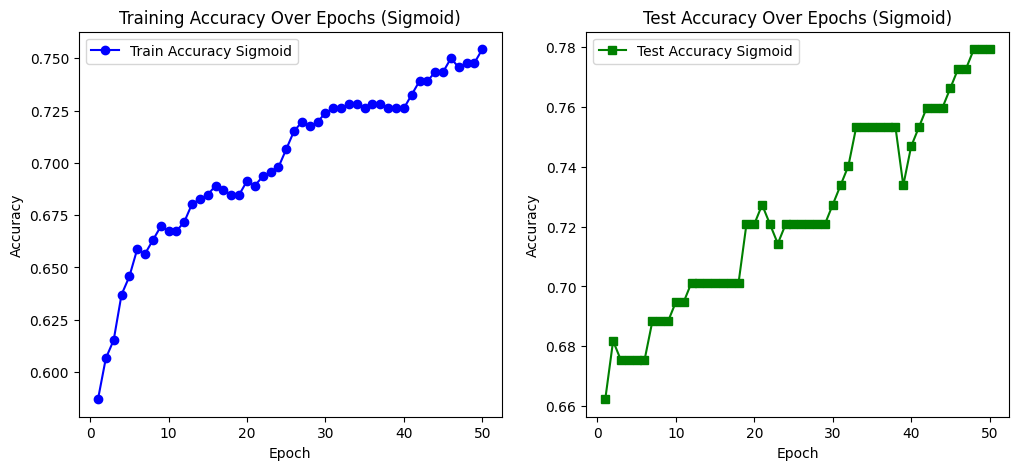

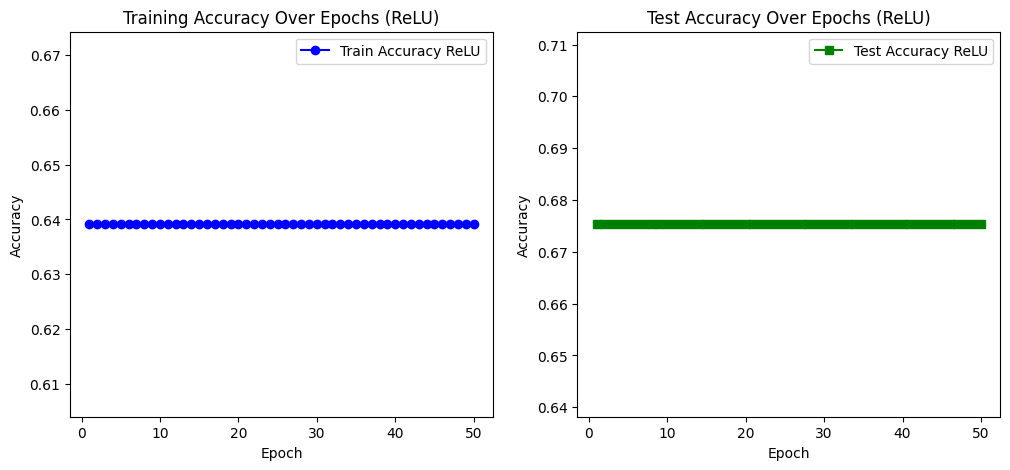

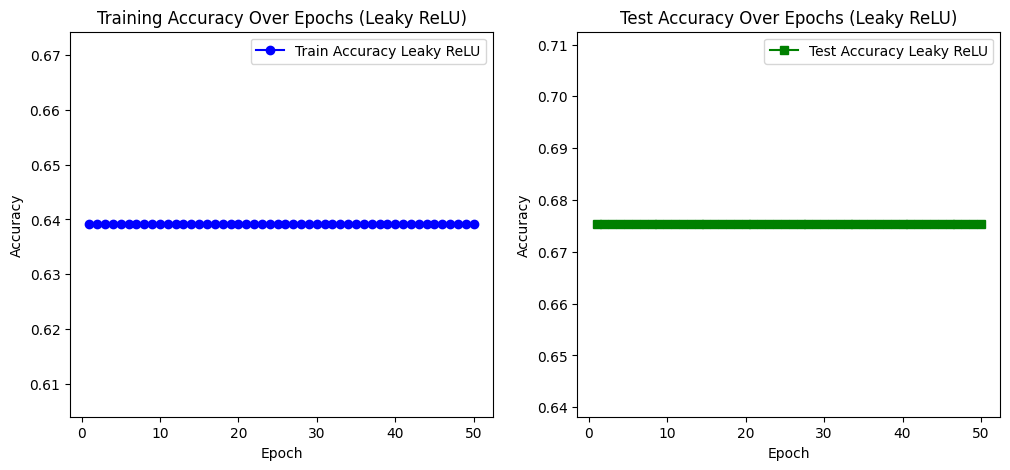

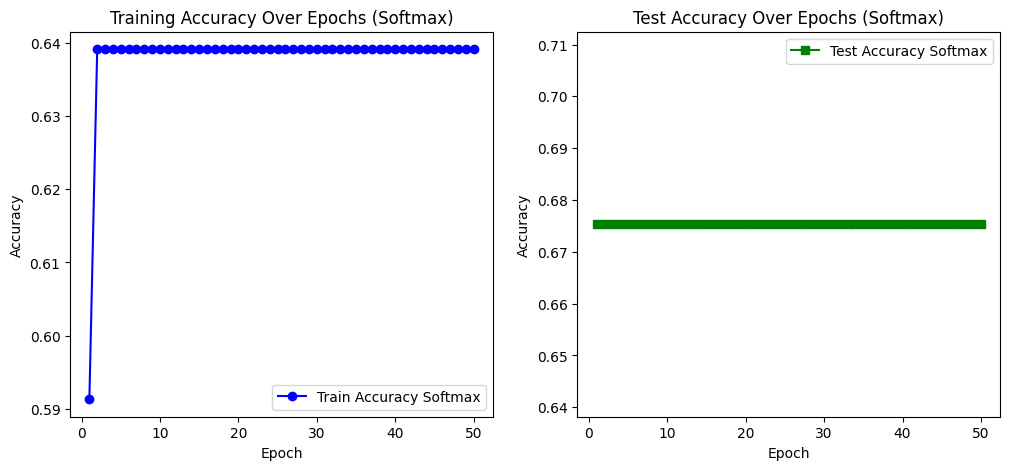

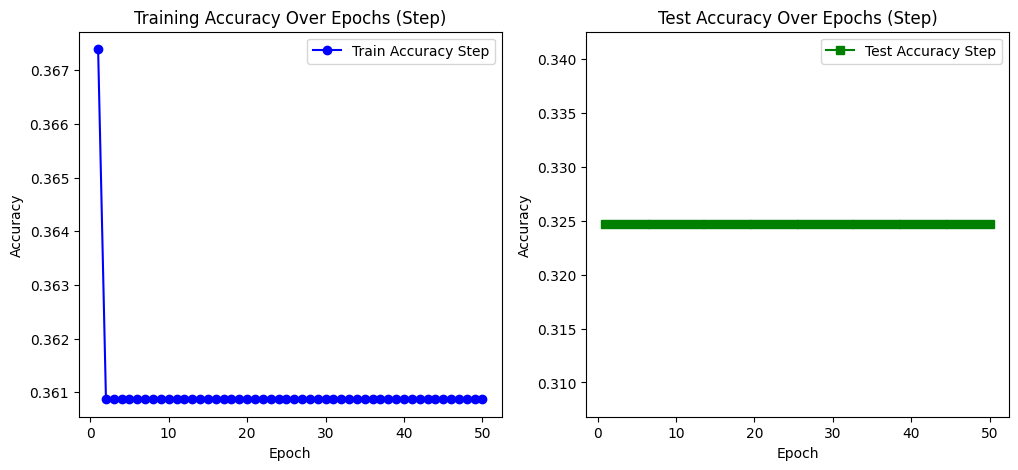

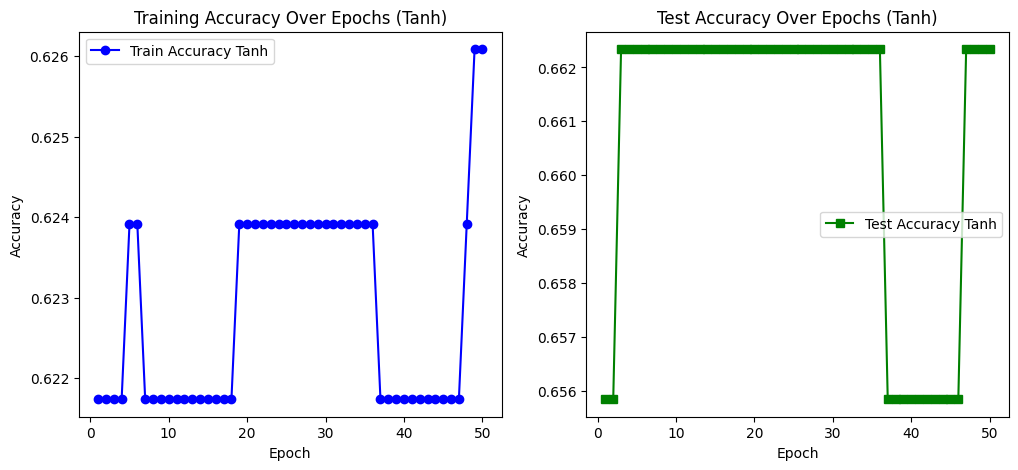

In [47]:
# don't change this cell
for model_name in metrics_df["Model"].unique():
    df_model = metrics_df[metrics_df["Model"] == model_name]
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(df_model["Epoch"], df_model["Train_Accuracy"], marker='o', linestyle='-', color='b',
             label=f"Train Accuracy {model_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Training Accuracy Over Epochs ({model_name})")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(df_model["Epoch"], df_model["Test_Accuracy"], marker='s', linestyle='-', color='g',
             label=f"Test Accuracy {model_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Test Accuracy Over Epochs ({model_name})")
    plt.legend()

    plt.show()